# Tech Challenge — Fase 1
## Desafio 4: Modelo Preditivo de NPS
Grupo: André, Fernanda, Isabela, Nicole, Thyago

> **Objetivo:** Prever se um cliente será **Detrator** (NPS 0–6) antes da aplicação da pesquisa,  
> utilizando apenas dados operacionais disponíveis durante a jornada de compra.

---


## 1. Importações e Configurações

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, roc_curve, f1_score, accuracy_score,
    precision_score, recall_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#2C3E50', '#E74C3C', '#27AE60', '#2980B9', '#F39C12', '#8E44AD']

print(" Bibliotecas carregadas com sucesso!")


 Bibliotecas carregadas com sucesso!


## 2. Estratégia de Modelagem

Duas abordagens foram consideradas para resolver o problema:

| Abordagem | Descrição | Decisão |
|---|---|---|
| **Regressão** | Prever o valor numérico exato do NPS (0–10) | ❌ Descartada |
| **Classificação Binária** | Prever se o cliente será Detrator (NPS ≤ 6) ou Não-Detrator (NPS ≥ 7) | ✅ Adotada |

### Por que Classificação Binária?

- **Alinhamento com o negócio:** a empresa não precisa saber se o cliente dará 6.2 ou 6.8 — ela precisa saber **quem agir antes que se torne um detrator**.
- **Definição padrão do NPS (Bain & Co.):** Detratores = 0–6 | Neutros = 7–8 | Promotores = 9–10. Simplificamos para Detrator vs. Não-Detrator para maximizar o impacto operacional.
- **Performance:** dados de pesquisa de satisfação são ruidosos; classificação tende a ser mais estável que regressão nesses cenários.
- **Acionabilidade:** um alerta binário (🔴 Risco de Detrator) é mais fácil de integrar em CRM e dashboards operacionais.


## 3. Carregamento dos Dados

In [30]:
df = pd.read_csv('Dados/cliente_nps.csv')

print(f"Shape: {df.shape[0]} registros | {df.shape[1]} variáveis")
print(f"\nValores ausentes: {df.isnull().sum().sum()}")
df.head()


Shape: 2500 registros | 19 variáveis

Valores ausentes: 0


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [31]:
df.describe().round(2)


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


## 4. Definição da Variável-Alvo (`target_detrator`)

A variável-alvo é criada a partir do `nps_score`:

- **1 → Detrator:** NPS entre 0 e 6 (inclusive)
- **0 → Não-Detrator:** NPS entre 7 e 10

Essa categorização segue o padrão da metodologia NPS original.


Detratores  (NPS 0–6):     1,851 (74.0%)
Não-Detratores (NPS 7–10): 649 (26.0%)


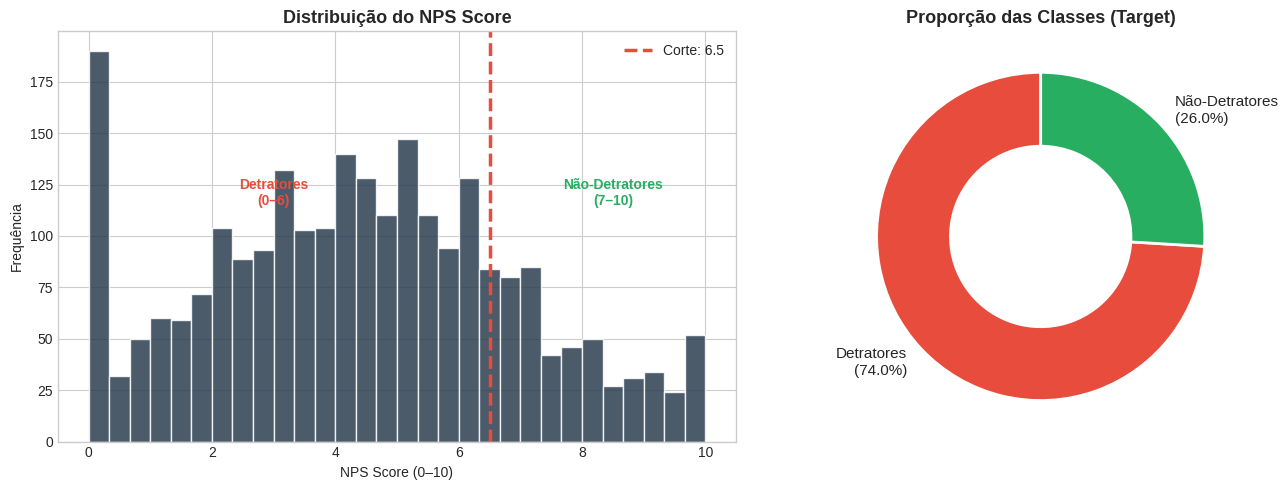

In [32]:
# Criação do target binário
df['target_detrator'] = (df['nps_score'] <= 6).astype(int)

n_detratores  = df['target_detrator'].sum()
n_ndetratores = len(df) - n_detratores
pct_det = n_detratores / len(df) * 100

print(f"Detratores  (NPS 0–6):     {n_detratores:,} ({pct_det:.1f}%)")
print(f"Não-Detratores (NPS 7–10): {n_ndetratores:,} ({100-pct_det:.1f}%)")

# ── Visualização ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma NPS com linha de corte
axes[0].hist(df['nps_score'], bins=30, color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].axvline(x=6.5, color=COLORS[1], linewidth=2.5, linestyle='--', label='Corte: 6.5')
axes[0].set_title('Distribuição do NPS Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('NPS Score (0–10)')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].annotate('Detratores\n(0–6)',       xy=(3,   115), fontsize=10, color=COLORS[1], fontweight='bold', ha='center')
axes[0].annotate('Não-Detratores\n(7–10)', xy=(8.5, 115), fontsize=10, color=COLORS[2], fontweight='bold', ha='center')

# Pizza de proporção
sizes  = [n_detratores, n_ndetratores]
labels = [f'Detratores\n({pct_det:.1f}%)', f'Não-Detratores\n({100-pct_det:.1f}%)']


axes[1].pie(
    sizes,
    labels=labels,
    colors=[COLORS[1], COLORS[2]],
    startangle=90,
    labeldistance=1.12,
    textprops={'fontsize': 11},
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 2,
        'width': 0.45
    }
)


axes[1].set_title('Proporção das Classes (Target)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Seleção e Preparação das Variáveis de Entrada

### Variáveis excluídas por risco de vazamento de dados (*data leakage*)

| Variável | Motivo da exclusão |
|---|---|
| `nps_score` | É a fonte do target — não pode entrar como feature |
| `customer_id` / `order_id` | Apenas identificadores, sem valor preditivo |
| `csat_internal_score` | Score coletado **simultaneamente** ao NPS — não disponível antes da pesquisa |
| `repeat_purchase_30d` | Comportamento **posterior** à compra — não disponível no momento da previsão |

### Feature Engineering
Criamos 3 variáveis derivadas para capturar padrões operacionais críticos:
- `delivery_issue`: atraso OU múltiplas tentativas de entrega
- `service_issue`: múltiplos contatos OU muitas reclamações
- `high_delay`: atraso ≥ 2 dias (ponto de ruptura identificado na EDA)


In [33]:
# Encoding da variável categórica
le = LabelEncoder()
df['customer_region_enc'] = le.fit_transform(df['customer_region'])
print("Regiões mapeadas:", dict(zip(le.classes_, le.transform(le.classes_))))

# Feature Engineering
df['delivery_issue'] = ((df['delivery_delay_days'] > 0) | (df['delivery_attempts'] > 1)).astype(int)
df['service_issue']  = ((df['customer_service_contacts'] > 1) | (df['complaints_count'] > 2)).astype(int)
df['high_delay']     = (df['delivery_delay_days'] >= 2).astype(int)

# Lista final de features
FEATURES = [
    'customer_age', 'customer_tenure_months',
    'order_value', 'items_quantity', 'discount_value', 'payment_installments',
    'delivery_time_days', 'delivery_delay_days', 'freight_value',
    'delivery_attempts', 'customer_service_contacts', 'resolution_time_days',
    'complaints_count', 'customer_region_enc',
    'delivery_issue', 'service_issue', 'high_delay',
]

X = df[FEATURES]
y = df['target_detrator']

print(f"\nTotal de features: {len(FEATURES)}")
print(f"Shape de X: {X.shape}")
X.describe().round(2)


Regiões mapeadas: {'Centro-Oeste': np.int64(0), 'Nordeste': np.int64(1), 'Norte': np.int64(2), 'Sudeste': np.int64(3), 'Sul': np.int64(4)}

Total de features: 17
Shape de X: (2500, 17)


,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,complaints_count,customer_region_enc,delivery_issue,service_issue,high_delay
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,43.40,61.32,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.15,2.06,0.96,0.84,0.64
std,14.89,34.48,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,1.78,1.41,0.19,0.37,0.48
min,18.00,1.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,31.00,31.00,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,3.00,1.00,1.00,1.00,0.00
50%,43.00,62.00,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.00,2.00,1.00,1.00,1.00
75%,56.00,91.00,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,5.00,3.00,1.00,1.00,1.00
max,69.00,119.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,11.00,4.00,1.00,1.00,1.00


## 6. Separação dos Dados — Treino e Teste

Utilizamos **80% para treino** e **20% para teste**, com **estratificação** para garantir  
que a proporção de Detratores e Não-Detratores seja preservada em ambos os conjuntos.

Isso é importante porque as classes são desbalanceadas (~74% de Detratores).


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino : {X_train.shape[0]:,} registros | Detratores: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Teste  : {X_test.shape[0]:,} registros | Detratores: {y_test.sum()} ({y_test.mean():.1%})")

# Normalização para Regressão Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


Treino : 2,000 registros | Detratores: 1481 (74.1%)
Teste  : 500 registros | Detratores: 370 (74.0%)


## 7. Treinamento e Comparação de Modelos

Treinamos 4 modelos e comparamos com validação cruzada (5-fold estratificado):

| Modelo | Característica |
|---|---|
| **Baseline (Dummy)** | Sempre prevê a classe majoritária — referência mínima |
| **Regressão Logística** | Modelo linear interpretável — boa baseline estatística |
| **Random Forest** | Ensemble de árvores — robusto a outliers e não-linearidades |
| **XGBoost** | Gradient boosting — estado da arte para dados tabulares |

**Métricas escolhidas:**
- **AUC-ROC:** capacidade de separar as classes (independente do threshold)
- **F1-Score:** equilíbrio entre precisão e recall — adequado para classes desbalanceadas
- **Acurácia:** proporção geral de acertos (referência complementar)


In [35]:
modelos = {
    'Baseline (Dummy)':    DummyClassifier(strategy='most_frequent', random_state=42),
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced'),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                         random_state=42, eval_metric='logloss',
                                         scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
}

skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}

for nome, modelo in modelos.items():
    X_tr = X_train_sc if 'Logística' in nome else X_train
    X_te = X_test_sc  if 'Logística' in nome else X_test

    cv_scores = cross_val_score(modelo, X_tr, y_train, cv=skf, scoring='roc_auc')
    modelo.fit(X_tr, y_train)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1] if hasattr(modelo, 'predict_proba') else None

    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else 0.5
    resultados[nome] = {
        'modelo': modelo, 'y_pred': y_pred, 'y_prob': y_prob, 'X_te': X_te,
        'AUC-ROC': auc,
        'Acurácia': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'CV AUC (mean)': cv_scores.mean(),
        'CV AUC (std)':  cv_scores.std(),
    }

# Tabela resumo
df_res = pd.DataFrame({
    k: {m: v[m] for m in ['AUC-ROC', 'Acurácia', 'F1-Score', 'CV AUC (mean)', 'CV AUC (std)']}
    for k, v in resultados.items()
}).T.round(4)

print("Resultados dos modelos:")
df_res


Resultados dos modelos:


,AUC-ROC,Acurácia,F1-Score,CV AUC (mean),CV AUC (std)
Baseline (Dummy),0.5000,0.740,0.8506,0.5000,0.0000
Regressão Logística,0.8800,0.800,0.8547,0.8782,0.0116
Random Forest,0.8686,0.830,0.8831,0.8702,0.0134
XGBoost,0.8621,0.796,0.8595,0.8548,0.0108


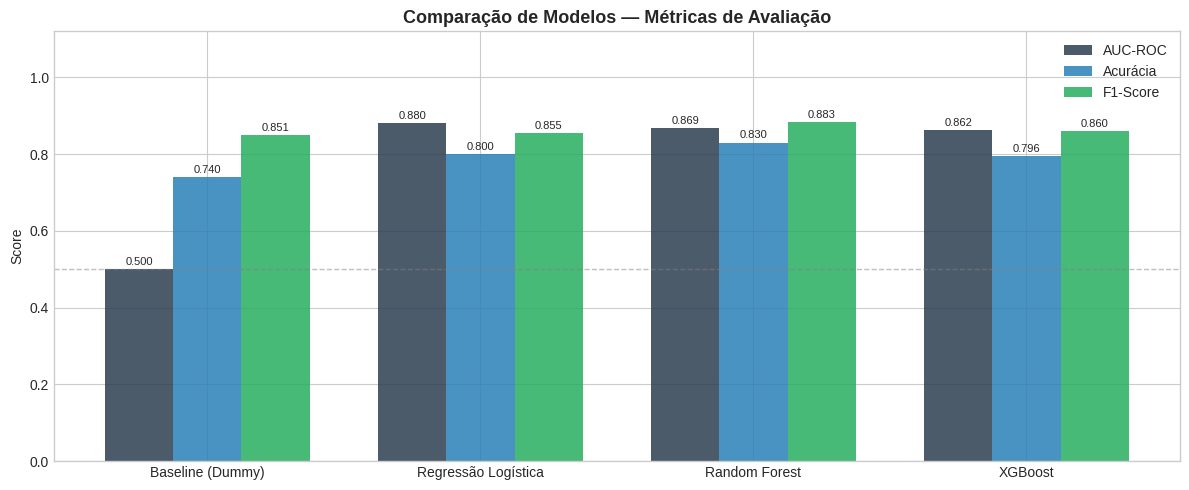

In [36]:
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(df_res))
width = 0.25

ax.bar(x - width, df_res['AUC-ROC'],  width, label='AUC-ROC',  color=COLORS[0], alpha=0.85)
ax.bar(x,          df_res['Acurácia'], width, label='Acurácia', color=COLORS[3], alpha=0.85)
ax.bar(x + width,  df_res['F1-Score'], width, label='F1-Score', color=COLORS[2], alpha=0.85)

for bars_data, offset in zip(['AUC-ROC', 'Acurácia', 'F1-Score'], [-width, 0, width]):
    for i, val in enumerate(df_res[bars_data]):
        ax.annotate(f'{val:.3f}', xy=(x[i] + offset, val),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_res.index, fontsize=10)
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Comparação de Modelos — Métricas de Avaliação', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


## 8. Modelo Vencedor: Random Forest 🏆

### Por que Random Forest?

- **Melhor F1-Score no teste (0.883):** fundamental para dados desbalanceados
- **AUC-ROC competitivo (0.869):** boa separação entre classes
- **Estabilidade em CV:** baixo desvio padrão entre folds (0.013)
- **Interpretabilidade:** a importância das features ajuda a comunicar resultados ao negócio
- **Robusto a outliers:** não exige normalização, lida bem com variáveis de escalas distintas


In [37]:
rf_model  = resultados['Random Forest']['modelo']
y_pred_rf = resultados['Random Forest']['y_pred']
y_prob_rf = resultados['Random Forest']['y_prob']

print("Relatório de Classificação — Random Forest")
print("=" * 50)
print(classification_report(y_test, y_pred_rf, target_names=['Não-Detrator', 'Detrator']))


Relatório de Classificação — Random Forest
              precision    recall  f1-score   support

Não-Detrator       0.66      0.72      0.69       130
    Detrator       0.90      0.87      0.88       370

    accuracy                           0.83       500
   macro avg       0.78      0.80      0.79       500
weighted avg       0.84      0.83      0.83       500



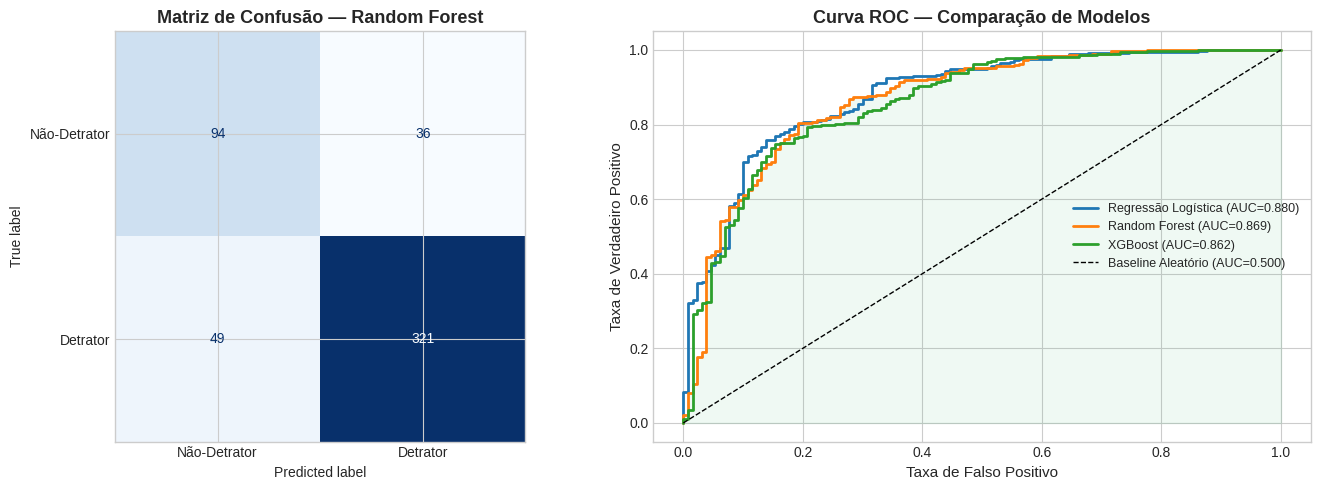

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm, display_labels=['Não-Detrator', 'Detrator']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Random Forest', fontsize=13, fontweight='bold')

# Curva ROC
for nome, res in resultados.items():
    if res['y_prob'] is not None and nome != 'Baseline (Dummy)':
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        axes[1].plot(fpr, tpr, linewidth=2, label=f"{nome} (AUC={res['AUC-ROC']:.3f})")

axes[1].plot([0,1],[0,1], 'k--', linewidth=1, label='Baseline Aleatório (AUC=0.500)')
axes[1].fill_between(*roc_curve(y_test, y_prob_rf)[:2], alpha=0.07, color=COLORS[2])
axes[1].set_xlabel('Taxa de Falso Positivo', fontsize=11)
axes[1].set_ylabel('Taxa de Verdadeiro Positivo', fontsize=11)
axes[1].set_title('Curva ROC — Comparação de Modelos', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 9. Importância das Features

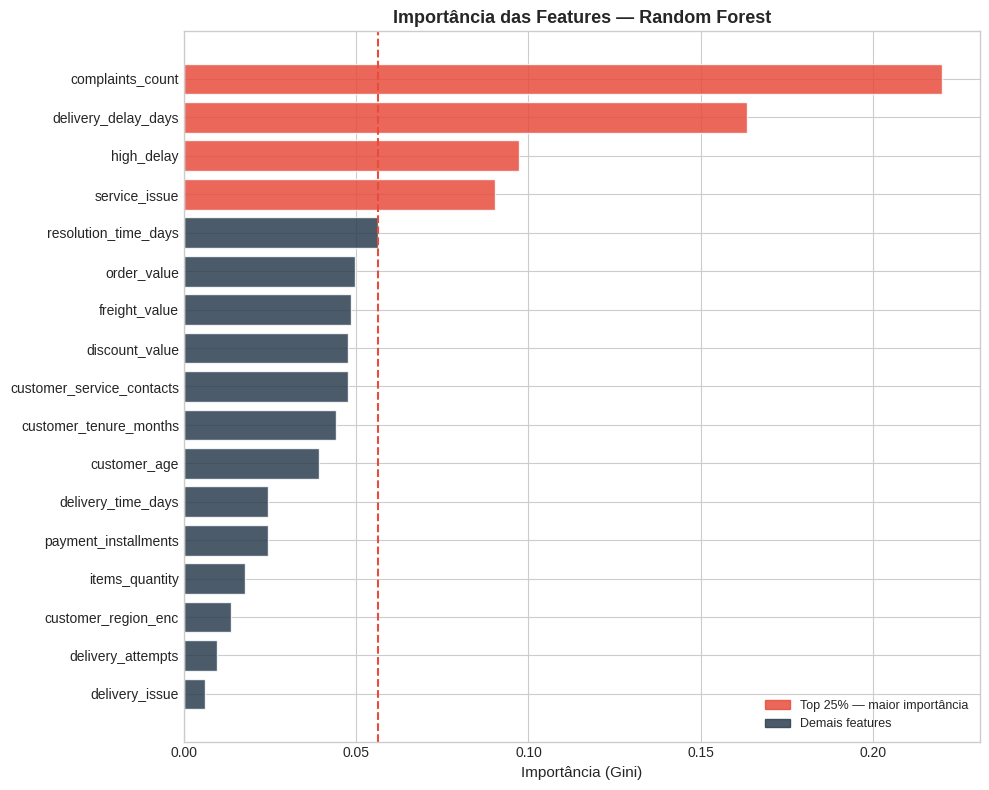


Top 5 features mais importantes:
  complaints_count                   : 0.2200
  delivery_delay_days                : 0.1635
  high_delay                         : 0.0973
  service_issue                      : 0.0904
  resolution_time_days               : 0.0563


In [39]:
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
q75 = importancias.quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = [COLORS[1] if imp > q75 else COLORS[0] for imp in importancias]
ax.barh(importancias.index, importancias.values, color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(q75, color=COLORS[1], linestyle='--', linewidth=1.5)
ax.set_title('Importância das Features — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância (Gini)', fontsize=11)

patch_alta  = mpatches.Patch(color=COLORS[1], alpha=0.85, label='Top 25% — maior importância')
patch_baixa = mpatches.Patch(color=COLORS[0], alpha=0.85, label='Demais features')
ax.legend(handles=[patch_alta, patch_baixa], fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 features mais importantes:")
for feat, imp in importancias.sort_values(ascending=False).head(5).items():
    print(f"  {feat:35s}: {imp:.4f}")


## 10. Calibração do Threshold de Decisão

O threshold padrão de 0.5 nem sempre é o ideal para o negócio.  
Aqui calibramos o ponto de corte considerando o **custo operacional** de:
- **Falso Negativo:** não alertar sobre um detrator real (custo alto — cliente insatisfeito não é atendido)
- **Falso Positivo:** alertar sobre alguém que não seria detrator (custo baixo — atendimento desnecessário)

Para este caso, priorizamos **recall alto** (capturar o máximo de detratores reais),  
aceitando um volume maior de alertas. O threshold **0.40** foi escolhido.


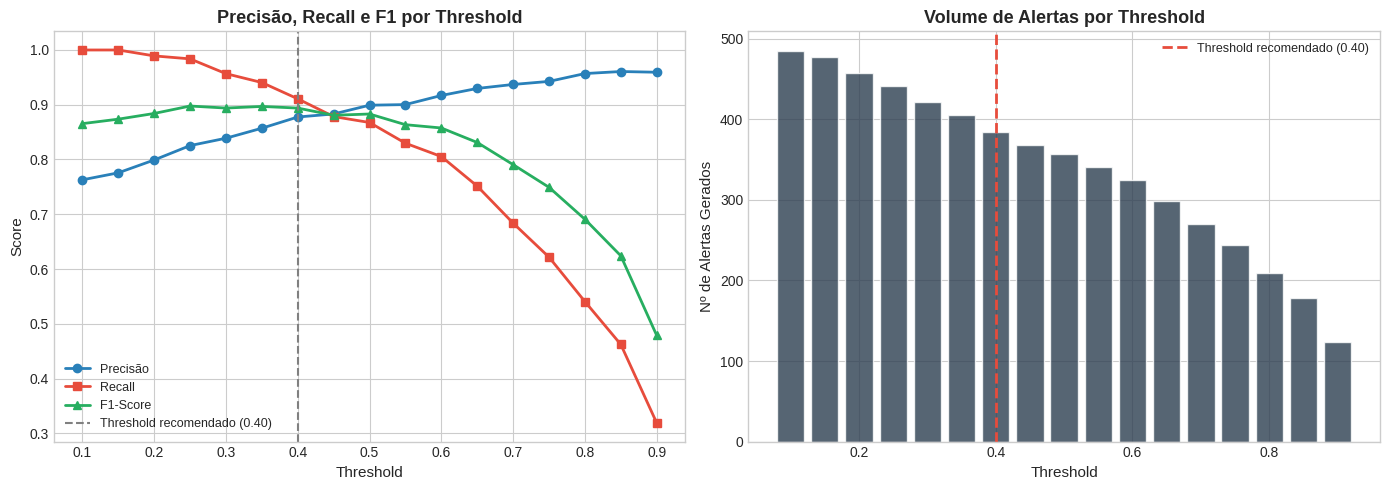

Threshold recomendado: 0.4
  Precisão : 0.878  → a cada 10 alertas, ~9 são detratores reais
  Recall   : 0.911  → captura 91% dos detratores reais
  Alertas  : 384 clientes no conjunto de teste


In [40]:
thresholds = np.arange(0.10, 0.91, 0.05)
res_thresh = []
for thr in thresholds:
    y_pred_thr = (y_prob_rf >= thr).astype(int)
    res_thresh.append({
        'Threshold': thr,
        'Precisão':  precision_score(y_test, y_pred_thr, zero_division=0),
        'Recall':    recall_score(y_test, y_pred_thr, zero_division=0),
        'F1':        f1_score(y_test, y_pred_thr, zero_division=0),
        'Alertas':   int(y_pred_thr.sum()),
    })

df_thresh = pd.DataFrame(res_thresh)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['Threshold'], df_thresh['Precisão'], 'o-', color=COLORS[3], linewidth=2, label='Precisão')
axes[0].plot(df_thresh['Threshold'], df_thresh['Recall'],   's-', color=COLORS[1], linewidth=2, label='Recall')
axes[0].plot(df_thresh['Threshold'], df_thresh['F1'],       '^-', color=COLORS[2], linewidth=2, label='F1-Score')
axes[0].axvline(0.40, color='gray', linestyle='--', linewidth=1.5, label='Threshold recomendado (0.40)')
axes[0].set_xlabel('Threshold', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Precisão, Recall e F1 por Threshold', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].bar(df_thresh['Threshold'], df_thresh['Alertas'], width=0.04, color=COLORS[0], alpha=0.8, edgecolor='white')
axes[1].axvline(0.40, color=COLORS[1], linestyle='--', linewidth=2, label='Threshold recomendado (0.40)')
axes[1].set_xlabel('Threshold', fontsize=11)
axes[1].set_ylabel('Nº de Alertas Gerados', fontsize=11)
axes[1].set_title('Volume de Alertas por Threshold', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Métricas no threshold escolhido
THR_REC = 0.40
y_pred_rec = (y_prob_rf >= THR_REC).astype(int)
print(f"Threshold recomendado: {THR_REC}")
print(f"  Precisão : {precision_score(y_test, y_pred_rec):.3f}  → a cada 10 alertas, ~{precision_score(y_test, y_pred_rec)*10:.0f} são detratores reais")
print(f"  Recall   : {recall_score(y_test, y_pred_rec):.3f}  → captura {recall_score(y_test, y_pred_rec):.0%} dos detratores reais")
print(f"  Alertas  : {y_pred_rec.sum()} clientes no conjunto de teste")


## 11. Simulação de Uso em Produção — Scoring de Novos Pedidos

Esta célula demonstra como o modelo seria utilizado em produção:  
dados operacionais de um pedido recém-despachado são passados ao modelo,  
que retorna a probabilidade de o cliente se tornar um detrator.


In [41]:
novos_pedidos = pd.DataFrame({
    'customer_age':             [45, 30, 60, 22, 55],
    'customer_tenure_months':   [24,  6, 48,  3, 36],
    'order_value':              [320.0, 80.0, 540.0, 110.0, 250.0],
    'items_quantity':           [3, 1, 5, 2, 4],
    'discount_value':           [30.0, 5.0, 80.0, 10.0, 20.0],
    'payment_installments':     [3, 1, 6, 1, 4],
    'delivery_time_days':       [5, 3, 12, 2, 7],
    'delivery_delay_days':      [0, 0, 5, 0, 3],
    'freight_value':            [15.0, 8.0, 35.0, 5.0, 20.0],
    'delivery_attempts':        [1, 1, 3, 1, 2],
    'customer_service_contacts':[0, 0, 4, 0, 2],
    'resolution_time_days':     [0, 0, 7, 0, 3],
    'complaints_count':         [0, 0, 5, 0, 2],
    'customer_region_enc':      [2, 0, 1, 3, 2],
    'delivery_issue':           [0, 0, 1, 0, 1],
    'service_issue':            [0, 0, 1, 0, 1],
    'high_delay':               [0, 0, 1, 0, 1],
})

probs   = rf_model.predict_proba(novos_pedidos[FEATURES])[:, 1]
alertas = (probs >= THR_REC).astype(int)

resultado_scoring = pd.DataFrame({
    'Pedido':          [f'Pedido_{i+1}' for i in range(len(novos_pedidos))],
    'P(Detrator)':     [f'{p:.1%}' for p in probs],
    'Alerta?':         ['🔴 SIM' if a else '🟢 NÃO' for a in alertas],
    'Prioridade':      ['🔴 ALTA' if p >= 0.6 else ('🟡 MÉDIA' if p >= 0.4 else '🟢 BAIXA') for p in probs],
    'Atraso (dias)':   novos_pedidos['delivery_delay_days'].values,
    'Reclamações':     novos_pedidos['complaints_count'].values,
    'Contatos Atend.': novos_pedidos['customer_service_contacts'].values,
})

resultado_scoring


,Pedido,P(Detrator),Alerta?,Prioridade,Atraso (dias),Reclamações,Contatos Atend.
0,Pedido_1,6.3%,🟢 NÃO,🟢 BAIXA,0,0,0
1,Pedido_2,32.3%,🟢 NÃO,🟢 BAIXA,0,0,0
2,Pedido_3,98.3%,🔴 SIM,🔴 ALTA,5,5,4
3,Pedido_4,28.3%,🟢 NÃO,🟢 BAIXA,0,0,0
4,Pedido_5,47.5%,🔴 SIM,🟡 MÉDIA,3,2,2


## 12. Pipeline de Uso em Produção

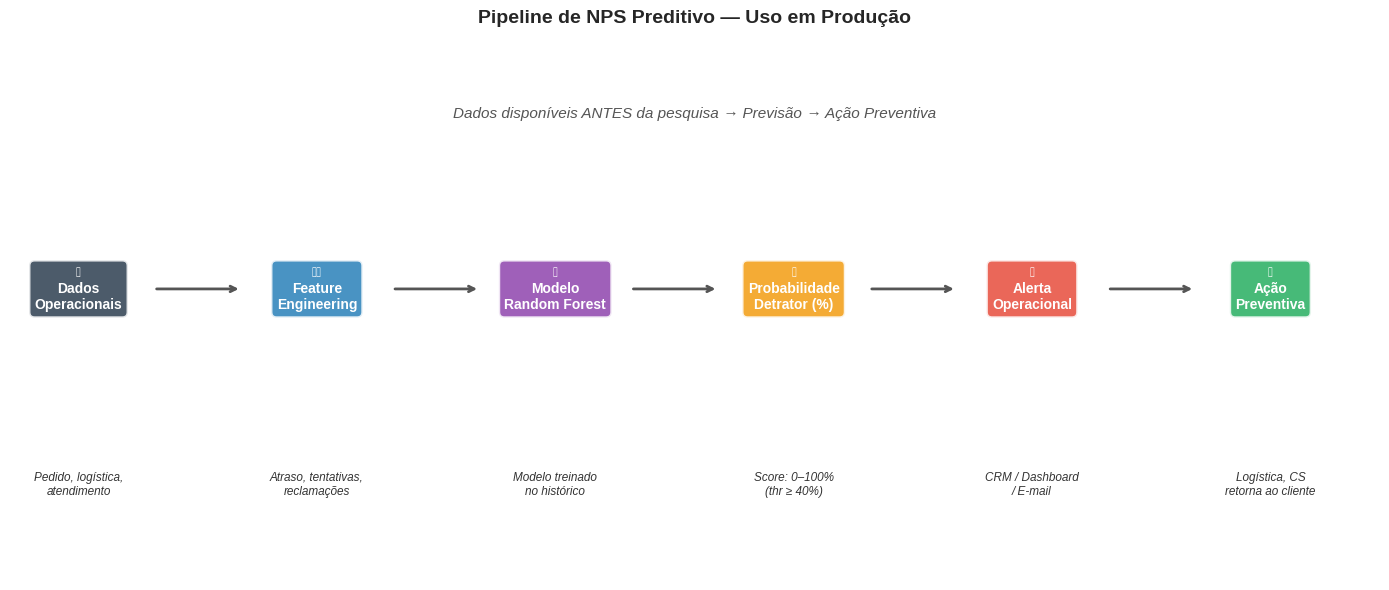

In [42]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

etapas = [
    ('📦\nDados\nOperacionais', '#2C3E50'),
    ('⚙️\nFeature\nEngineering', '#2980B9'),
    ('🤖\nModelo\nRandom Forest', '#8E44AD'),
    ('📊\nProbabilidade\nDetrator (%)', '#F39C12'),
    ('🚨\nAlerta\nOperacional', '#E74C3C'),
    ('✅\nAção\nPreventiva', '#27AE60'),
]
descricoes = [
    'Pedido, logística,\natendimento',
    'Atraso, tentativas,\nreclamações',
    'Modelo treinado\nno histórico',
    'Score: 0–100%\n(thr ≥ 40%)',
    'CRM / Dashboard\n/ E-mail',
    'Logística, CS\nretorna ao cliente',
]

x_pos = np.linspace(0.05, 0.92, len(etapas))
y_box = 0.55
for i, ((label, color), desc) in enumerate(zip(etapas, descricoes)):
    box = dict(boxstyle='round,pad=0.4', facecolor=color, alpha=0.85, edgecolor='white', linewidth=2)
    ax.text(x_pos[i], y_box, label, ha='center', va='center', fontsize=10,
            color='white', fontweight='bold', bbox=box, transform=ax.transAxes)
    ax.text(x_pos[i], 0.18, desc, ha='center', va='center', fontsize=8.5,
            color='#333333', transform=ax.transAxes, style='italic')
    if i < len(etapas) - 1:
        ax.annotate('', xy=(x_pos[i+1] - 0.055, y_box), xytext=(x_pos[i] + 0.055, y_box),
                    xycoords='axes fraction', textcoords='axes fraction',
                    arrowprops=dict(arrowstyle='->', color='#555555', lw=2))

ax.set_title('Pipeline de NPS Preditivo — Uso em Produção', fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 0.88, 'Dados disponíveis ANTES da pesquisa → Previsão → Ação Preventiva',
        ha='center', va='center', fontsize=11, color='#555555',
        transform=ax.transAxes, style='italic')
plt.tight_layout()
plt.show()


## 13. Resumo e Limitações

### O que foi feito
| Etapa | Decisão |
|---|---|
| Abordagem | Classificação binária (Detrator vs. Não-Detrator) |
| Target | `nps_score ≤ 6` → Detrator |
| Features | 17 variáveis operacionais + feature engineering |
| Modelo | Random Forest (200 árvores, max_depth=8) |
| Threshold | 0.40 (recall prioritário) |
| AUC-ROC (teste) | ~0.87 |
| F1-Score (teste) | ~0.88 |

### Fatores mais importantes para a previsão
1. `complaints_count` — quantidade de reclamações
2. `delivery_delay_days` — dias de atraso na entrega
3. `high_delay` — atraso ≥ 2 dias (ponto de ruptura)
4. `service_issue` — problemas combinados no atendimento
5. `resolution_time_days` — tempo de resolução

### Limitações e Cuidados
- O modelo **não captura sentimento subjetivo** do cliente — dois clientes com o mesmo atraso podem ter percepções diferentes.
- **Data drift:** o comportamento dos clientes muda com o tempo; o modelo deve ser re-treinado periodicamente.
- **Base de 2.500 registros** — para produção, recomenda-se ampliar o volume de dados históricos.
- O `csat_internal_score` foi excluído por vazamento, mas poderia ser explorado em um cenário diferente (coleta antecipada).
- As features derivadas (`delivery_issue`, `service_issue`) foram criadas com base no domínio do problema — validar com especialistas operacionais.

### Como usar em produção
```python
# Após cada pedido despachado:
dados_pedido = {...}  # dados operacionais em tempo real
prob_detrator = rf_model.predict_proba(pd.DataFrame([dados_pedido])[FEATURES])[0][1]

if prob_detrator >= 0.40:
    acionar_alerta_crm(pedido_id, prioridade='ALTA' if prob_detrator >= 0.6 else 'MEDIA')
```
